# Phase 2 — Multiclass SVM for MNIST

## Objective

In Phase 1, the SVM model was implemented for binary classification: digit 1 vs all other digits.

In Phase 2, the problem is extended to multiclass classification with 10 MNIST classes:

$$
y \in \{0,1,2,3,4,5,6,7,8,9\}
$$

The goal of this notebook is to scale the SVM pipeline to 10 image classes while keeping the work consistent with Phase 1.

We evaluate:

1. One-vs-Rest Linear SVM
2. PCA features
3. HOG features

We also apply advanced machine learning techniques required in Phase 2:

- Feature engineering through PCA and HOG feature comparison
- Hyperparameter tuning with validation-set evaluation
- Regularization analysis through the SVM parameter \(C\)
- Overfitting and underfitting diagnosis using learning curves

We also apply advanced machine learning techniques required in Phase 2:

- Feature engineering through PCA and HOG feature comparison
- Hyperparameter tuning with validation / cross-validation
- Regularization analysis through the SVM parameter \(C\)
- Overfitting and underfitting diagnosis using learning curves

## 1. Import Libraries and Shared Project Functions

We import the required Python libraries and the shared project utilities.

For Phase 2:

- We still use the shared preprocessing function.
- We do not modify preprocessing.
- We use `binary=False` to keep all 10 MNIST classes.
- We use the shared multiclass metrics instead of the Phase 1 binary metrics.

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

from preprocessing.preprocess import preprocess
from evaluation.multiclass_metrics import evaluate_multiclass

np.random.seed(42)

os.makedirs("results/phase2", exist_ok=True)

print("Libraries and project functions imported successfully.")

Libraries and project functions imported successfully.


## 2. Load PCA and HOG Features for Multiclass MNIST

To keep this work consistent with Phase 1, we compare SVM performance using the same feature extraction methods:

1. PCA features
2. HOG features

The preprocessing function is used without modification.

The key Phase 2 change is:

```python
binary=False

In [14]:
print("Loading PCA features...")
X_tr_pca, X_val_pca, X_test_pca, y_tr, y_val, y_test = preprocess(
    feature_method="pca",
    binary=False,
    pca_components=100
)

print("\nLoading HOG features...")
X_tr_hog, X_val_hog, X_test_hog, y_tr_hog, y_val_hog, y_test_hog = preprocess(
    feature_method="hog",
    binary=False
)

print("\nPCA shapes:")
print("X_tr_pca:", X_tr_pca.shape)
print("X_val_pca:", X_val_pca.shape)
print("X_test_pca:", X_test_pca.shape)

print("\nHOG shapes:")
print("X_tr_hog:", X_tr_hog.shape)
print("X_val_hog:", X_val_hog.shape)
print("X_test_hog:", X_test_hog.shape)

print("\nUnique labels:")
print("Training labels:", np.unique(y_tr))
print("Validation labels:", np.unique(y_val))
print("Test labels:", np.unique(y_test))

print("\nDo PCA and HOG labels match?")
print("Train:", np.array_equal(y_tr, y_tr_hog))
print("Validation:", np.array_equal(y_val, y_val_hog))
print("Test:", np.array_equal(y_test, y_test_hog))

Loading PCA features...
 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 100
   Training shape     : (60000, 100)
   Test shape         : (10000, 100)
   Variance explained : 91.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
 

## 3. Full-Dataset Training Strategy

In this project, we do not reduce the dataset size.

However, Phase 2 multiclass SVM is computationally heavier than Phase 1 because One-vs-Rest training requires one binary SVM per class.

For MNIST:

$$
K = 10
$$

Therefore, we train:

$$
10
$$

binary SVM classifiers.

To keep full-dataset training feasible, we use mini-batch vectorized gradient descent.

This means:

- The full training dataset is used.
- The data is shuffled every epoch.
- Each update is computed on a mini-batch.
- NumPy vectorization avoids slow sample-by-sample loops.

This keeps the experiment valid while making training efficient in Colab.

In [15]:
def iterate_minibatches(X, y, batch_size=512, shuffle=True, seed=None):
    """
    Generate mini-batches from the full dataset.

    This does not reduce the dataset.
    It only splits the full dataset into smaller batches for efficient training.
    """
    n_samples = X.shape[0]

    indices = np.arange(n_samples)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_indices = indices[start_idx:end_idx]

        yield X[batch_indices], y[batch_indices]

# Mathematical Formulation — Multiclass Linear SVM

## 1. Binary Linear SVM

A standard Support Vector Machine is originally a binary classifier.

For binary classification, each label is encoded as:

$$
y_i \in \{-1, +1\}
$$

The linear SVM decision function is:

$$
f(x_i) = w^T x_i + b
$$

where:

- \(x_i\) is the input feature vector
- \(w\) is the weight vector
- \(b\) is the bias term

The prediction rule is:

$$
\hat{y}_i =
\begin{cases}
+1, & \text{if } f(x_i) \geq 0 \\
-1, & \text{if } f(x_i) < 0
\end{cases}
$$

The margin condition is:

$$
y_i(w^T x_i + b) \geq 1
$$

If this condition is satisfied, the sample is correctly classified and lies outside the margin.

---

## 2. Hinge Loss

SVM uses hinge loss to penalize misclassified samples and samples that lie inside the margin.

For one training sample, the hinge loss is:

$$
L_i = \max(0, 1 - y_i(w^T x_i + b))
$$

If:

$$
y_i(w^T x_i + b) \geq 1
$$

then:

$$
L_i = 0
$$

This means the sample is correctly classified and outside the margin.

If:

$$
y_i(w^T x_i + b) < 1
$$

then:

$$
L_i > 0
$$

This means the sample is either misclassified or inside the margin.

---

## 3. Soft-Margin Linear SVM Objective

The soft-margin Linear SVM objective combines margin maximization and hinge loss:

$$
J(w,b) =
\frac{1}{2}\|w\|^2
+
C \cdot \frac{1}{n}
\sum_{i=1}^{n}
\max(0, 1 - y_i(w^T x_i + b))
$$

where:

- \( \frac{1}{2}\|w\|^2 \) is the L2 regularization term.
- The hinge loss term penalizes margin violations.
- \(C\) controls the tradeoff between maximizing the margin and reducing classification errors.
- A smaller \(C\) gives stronger regularization and may lead to underfitting.
- A larger \(C\) gives weaker regularization and may lead to overfitting.

The bias term \(b\) is not regularized, which is standard in SVM implementations.

---

## 4. Gradient for Mini-Batch Training

To train efficiently on the full dataset, we use mini-batch gradient descent.

For a mini-batch of size \(m\), define the set of margin-violating samples as:

$$
V = \{i : y_i(w^T x_i + b) < 1\}
$$

Only samples in \(V\) contribute to the hinge-loss gradient.

The gradient with respect to \(w\) is:

$$
\nabla_w J =
w -
C \cdot \frac{1}{m}
\sum_{i \in V}
y_i x_i
$$

The gradient with respect to \(b\) is:

$$
\nabla_b J =
-
C \cdot \frac{1}{m}
\sum_{i \in V}
y_i
$$

The division is by the full mini-batch size \(m\), not only by the number of violating samples. This matches the objective function, where the hinge loss is averaged over the full batch.

The parameter update rules are:

$$
w := w - \eta \nabla_w J
$$

$$
b := b - \eta \nabla_b J
$$

where:

- \( \eta \) is the learning rate.
- \( \nabla_w J \) is the gradient with respect to \(w\).
- \( \nabla_b J \) is the gradient with respect to \(b\).

---

## 5. Multiclass Extension Using One-vs-Rest

MNIST is a multiclass classification problem with 10 classes:

$$
y \in \{0,1,2,3,4,5,6,7,8,9\}
$$

Since standard SVM is binary, we extend it to multiclass classification using the One-vs-Rest strategy.

For each class \(k\), we train one binary SVM classifier.

The binary labels for class \(k\) are defined as:

$$
y_i^{(k)} =
\begin{cases}
+1, & \text{if } y_i = k \\
-1, & \text{if } y_i \neq k
\end{cases}
$$

For MNIST, this gives 10 binary classifiers:

$$
0 \text{ vs rest},\;
1 \text{ vs rest},\;
2 \text{ vs rest},\;
\dots,\;
9 \text{ vs rest}
$$

Each class-specific SVM learns its own parameters:

$$
w_k, b_k
$$

and produces a class score:

$$
s_k(x) = w_k^T x + b_k
$$

The final multiclass prediction is the class with the highest score:

$$
\hat{y} =
\arg\max_{k \in \{0,1,\dots,9\}}
s_k(x)
$$

This is a direct extension of the Phase 1 binary SVM.  
In Phase 1, the task was:

$$
1 \text{ vs rest}
$$

In Phase 2, the task becomes:

$$
0 \text{ vs rest},\;
1 \text{ vs rest},\;
\dots,\;
9 \text{ vs rest}
$$

---

## 6. Feature Representations Used with SVM

To keep the Phase 2 SVM work consistent with Phase 1, two feature representations are compared:

### PCA Features

Principal Component Analysis projects the original image features into a lower-dimensional space:

$$
z = W^T x
$$

where:

- \(x\) is the original image feature vector
- \(W\) contains the principal component directions
- \(z\) is the reduced PCA feature vector

PCA preserves directions of high variance, but it may remove local structural information that is useful for distinguishing handwritten digits.

### HOG Features

Histogram of Oriented Gradients represents local edge and gradient directions in the image.

HOG is useful for MNIST because handwritten digits are strongly defined by:

- stroke direction
- edge patterns
- local shape structure

These features are highly relevant for distinguishing digit classes.

---

## 7. Evaluation Metrics for Multiclass Classification

For multiclass classification, the confusion matrix has size:

$$
10 \times 10
$$

Rows represent true labels, and columns represent predicted labels.

Accuracy is computed as:

$$
\text{Accuracy} =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

For each class \(k\), precision is:

$$
\text{Precision}_k =
\frac{TP_k}{TP_k + FP_k}
$$

Recall is:

$$
\text{Recall}_k =
\frac{TP_k}{TP_k + FN_k}
$$

F1-score is:

$$
F1_k =
\frac{2 \cdot \text{Precision}_k \cdot \text{Recall}_k}
{\text{Precision}_k + \text{Recall}_k}
$$

Macro F1-score treats all classes equally:

$$
\text{Macro F1} =
\frac{1}{K}
\sum_{k=1}^{K}
F1_k
$$

Weighted F1-score accounts for the number of samples in each class:

$$
\text{Weighted F1} =
\sum_{k=1}^{K}
\frac{n_k}{n}
F1_k
$$

where:

- \(K = 10\) is the number of classes
- \(n_k\) is the number of samples in class \(k\)
- \(n\) is the total number of samples

In [36]:
class BinaryLinearSVM:
    """
    Binary Linear SVM trained using mini-batch vectorized gradient descent.

    Labels must be:
        +1 for the target class
        -1 for all other classes

    Objective:
        J(w,b) = 0.5 * ||w||^2
                 + C * mean(max(0, 1 - y * (Xw + b)))
    """

    def __init__(self, C=1.0, learning_rate=0.001, n_epochs=20, batch_size=512):
        self.C = C
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size

        self.w = None
        self.b = 0.0
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.w = np.zeros(n_features, dtype=np.float32)
        self.b = 0.0
        self.loss_history = []

        X = X.astype(np.float32)
        y = y.astype(np.float32)

        for epoch in range(self.n_epochs):
            epoch_losses = []

            for X_batch, y_batch in iterate_minibatches(
                X,
                y,
                batch_size=self.batch_size,
                shuffle=True,
                seed=epoch
            ):
                current_batch_size = X_batch.shape[0]

                scores = np.dot(X_batch, self.w) + self.b
                margins = y_batch * scores

                violations = margins < 1

                hinge_losses = np.maximum(0, 1 - margins)

                objective = (
                    0.5 * np.dot(self.w, self.w)
                    + self.C * np.mean(hinge_losses)
                )

                epoch_losses.append(objective)

                # Correct gradient normalization: divide by full batch size,
                # not only by the number of violating samples.
                if np.any(violations):
                    dw = self.w - self.C * (
                        np.dot(X_batch[violations].T, y_batch[violations])
                        / current_batch_size
                    )

                    db = -self.C * (
                        np.sum(y_batch[violations])
                        / current_batch_size
                    )
                else:
                    dw = self.w
                    db = 0.0

                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

            mean_epoch_loss = np.mean(epoch_losses)
            self.loss_history.append(mean_epoch_loss)

            print(
                f"Epoch {epoch + 1}/{self.n_epochs} "
                f"— Objective: {mean_epoch_loss:.4f}"
            )

        return self

    def decision_function(self, X):
        X = X.astype(np.float32)
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)

In [37]:
class OneVsRestLinearSVM:
    """
    Multiclass Linear SVM using One-vs-Rest strategy.
    """

    def __init__(self, C=1.0, learning_rate=0.001, n_epochs=20, batch_size=512):
        self.C = C
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size

        self.classes_ = None
        self.classifiers = {}

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.classifiers = {}

        for class_label in self.classes_:
            print("=" * 70)
            print(f"Training Linear SVM for class {class_label} vs rest")
            print("=" * 70)

            y_binary = np.where(y == class_label, 1, -1)

            clf = BinaryLinearSVM(
                C=self.C,
                learning_rate=self.learning_rate,
                n_epochs=self.n_epochs,
                batch_size=self.batch_size
            )

            clf.fit(X, y_binary)
            self.classifiers[class_label] = clf

        print("One-vs-Rest Linear SVM training completed.")
        return self

    def decision_function(self, X):
        scores = np.zeros((X.shape[0], len(self.classes_)))

        for idx, class_label in enumerate(self.classes_):
            clf = self.classifiers[class_label]
            scores[:, idx] = clf.decision_function(X)

        return scores

    def predict(self, X):
        scores = self.decision_function(X)
        best_indices = np.argmax(scores, axis=1)
        return self.classes_[best_indices]

    def plot_loss_curves(self, title, save_path=None):
        plt.figure(figsize=(10, 6))

        for class_label, clf in self.classifiers.items():
            plt.plot(clf.loss_history, label=f"Class {class_label} vs rest")

        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("SVM Objective")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")

        plt.show()

## 5. Train One-vs-Rest Linear SVM on Full PCA Training Data

This experiment trains the multiclass Linear SVM on the full PCA training set.

PCA is used as one of the feature representations to stay consistent with Phase 1.

In [38]:
linear_svm_pca = OneVsRestLinearSVM(
    C=1.0,
    learning_rate=0.001,
    n_epochs=20,
    batch_size=512
)

linear_svm_pca.fit(X_tr_pca, y_tr)

y_val_pred_linear_pca = linear_svm_pca.predict(X_val_pca)

print("Predicted labels:", np.unique(y_val_pred_linear_pca))

Training Linear SVM for class 0 vs rest
Epoch 1/20 — Objective: 0.9593
Epoch 2/20 — Objective: 0.8794
Epoch 3/20 — Objective: 0.8028
Epoch 4/20 — Objective: 0.7290
Epoch 5/20 — Objective: 0.6574
Epoch 6/20 — Objective: 0.5878
Epoch 7/20 — Objective: 0.5197
Epoch 8/20 — Objective: 0.4531
Epoch 9/20 — Objective: 0.3886
Epoch 10/20 — Objective: 0.3289
Epoch 11/20 — Objective: 0.2790
Epoch 12/20 — Objective: 0.2433
Epoch 13/20 — Objective: 0.2215
Epoch 14/20 — Objective: 0.2085
Epoch 15/20 — Objective: 0.2001
Epoch 16/20 — Objective: 0.1946
Epoch 17/20 — Objective: 0.1909
Epoch 18/20 — Objective: 0.1882
Epoch 19/20 — Objective: 0.1863
Epoch 20/20 — Objective: 0.1849
Training Linear SVM for class 1 vs rest
Epoch 1/20 — Objective: 0.9602
Epoch 2/20 — Objective: 0.8824
Epoch 3/20 — Objective: 0.8082
Epoch 4/20 — Objective: 0.7372
Epoch 5/20 — Objective: 0.6686
Epoch 6/20 — Objective: 0.6021
Epoch 7/20 — Objective: 0.5374
Epoch 8/20 — Objective: 0.4743
Epoch 9/20 — Objective: 0.4139
Epoch 10/2

Multiclass Classification Report — One-vs-Rest Linear SVM — PCA Full Training Data
Accuracy           : 0.8093 (80.93%)
Macro Precision    : 0.8214
Macro Recall       : 0.8048
Macro F1-score     : 0.8027
Weighted Precision : 0.8190
Weighted Recall    : 0.8093
Weighted F1-score  : 0.8040
----------------------------------------------------------------------
Class 0: Precision=0.8163 | Recall=0.9489 | F1=0.8776 | Support=1175
Class 1: Precision=0.7152 | Recall=0.9690 | F1=0.8230 | Support=1322
Class 2: Precision=0.8573 | Recall=0.7624 | F1=0.8070 | Support=1174
Class 3: Precision=0.7729 | Recall=0.8039 | F1=0.7881 | Support=1219
Class 4: Precision=0.8494 | Recall=0.8827 | F1=0.8657 | Support=1176
Class 5: Precision=0.8868 | Recall=0.5109 | F1=0.6483 | Support=1104
Class 6: Precision=0.8367 | Recall=0.9184 | F1=0.8757 | Support=1177
Class 7: Precision=0.7659 | Recall=0.8814 | F1=0.8196 | Support=1299
Class 8: Precision=0.8188 | Recall=0.6897 | F1=0.7487 | Support=1160
Class 9: Precision=0

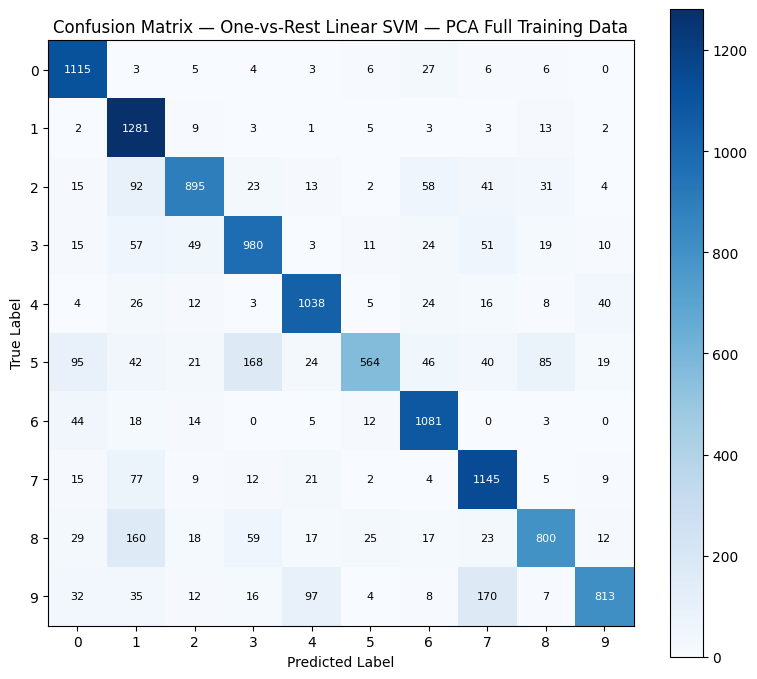

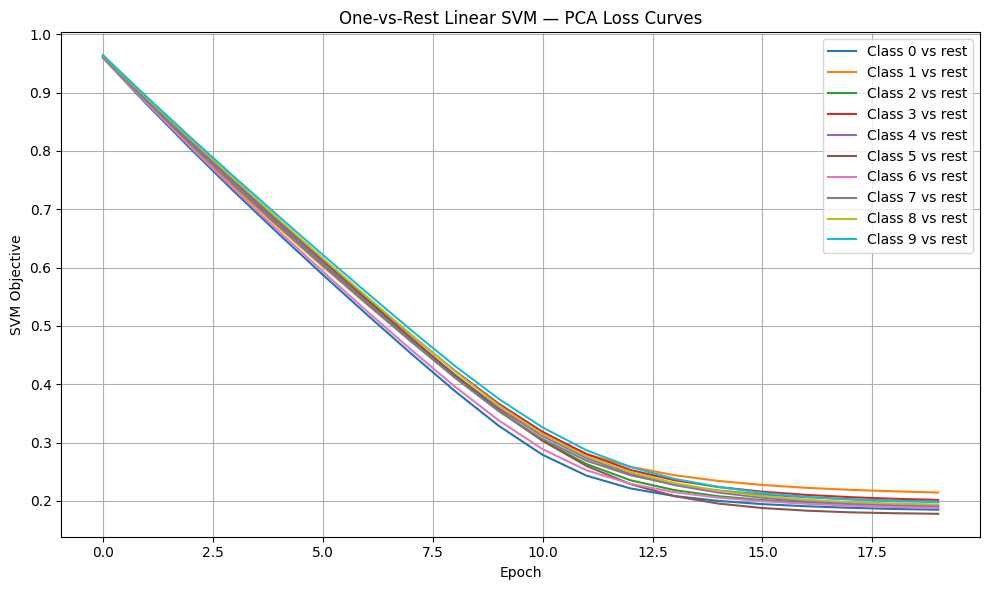

{'model': 'One-vs-Rest Linear SVM — PCA Full Training Data',
 'accuracy': np.float64(0.8093333333333333),
 'macro_precision': np.float64(0.8213660884400484),
 'macro_recall': np.float64(0.8048177437341997),
 'macro_f1': np.float64(0.8026902270277996),
 'weighted_precision': np.float64(0.8190485509448259),
 'weighted_recall': np.float64(0.8093333333333333),
 'weighted_f1': np.float64(0.8040118136280979),
 'per_class_precision': array([0.81625183, 0.71524288, 0.85727969, 0.77287066, 0.84942717,
        0.88679245, 0.83668731, 0.76588629, 0.81883316, 0.89438944]),
 'per_class_recall': array([0.94893617, 0.96898638, 0.76235094, 0.80393765, 0.88265306,
        0.51086957, 0.9184367 , 0.88144727, 0.68965517, 0.68090452]),
 'per_class_f1': array([0.87760724, 0.82300032, 0.80703336, 0.78809811, 0.86572143,
        0.64827586, 0.87565816, 0.81961346, 0.74871315, 0.77318117])}

In [40]:
linear_pca_results = evaluate_multiclass(
    y_val,
    y_val_pred_linear_pca,
    model_name="One-vs-Rest Linear SVM — PCA Full Training Data",
    num_classes=10,
    plot=True,
    save_confusion_path="results/phase2/linear_svm_pca_confusion_matrix.png",
    save_csv_path="results/phase2/phase2_results.csv"
)

linear_svm_pca.plot_loss_curves(
    title="One-vs-Rest Linear SVM — PCA Loss Curves",
    save_path="results/phase2/linear_svm_pca_loss_curves.png"
)

linear_pca_results

## 6. Train One-vs-Rest Linear SVM on HOG Features

Next, we train the same multiclass Linear SVM using HOG features.

HOG features describe local gradient and edge structure in the image.

This is useful for MNIST because digit identity depends heavily on shape, stroke direction, and edge patterns.

This experiment answers:

> How well does a multiclass Linear SVM perform on HOG features compared with PCA features?

In [41]:
linear_svm_hog = OneVsRestLinearSVM(
    C=1.0,
    learning_rate=0.001,
    n_epochs=20,
    batch_size=512
)

linear_svm_hog.fit(X_tr_hog, y_tr_hog)

y_val_pred_linear_hog = linear_svm_hog.predict(X_val_hog)

print("Predicted labels:", np.unique(y_val_pred_linear_hog))

Training Linear SVM for class 0 vs rest
Epoch 1/20 — Objective: 0.8594
Epoch 2/20 — Objective: 0.6807
Epoch 3/20 — Objective: 0.5692
Epoch 4/20 — Objective: 0.4863
Epoch 5/20 — Objective: 0.4206
Epoch 6/20 — Objective: 0.3658
Epoch 7/20 — Objective: 0.3193
Epoch 8/20 — Objective: 0.2797
Epoch 9/20 — Objective: 0.2455
Epoch 10/20 — Objective: 0.2164
Epoch 11/20 — Objective: 0.1918
Epoch 12/20 — Objective: 0.1717
Epoch 13/20 — Objective: 0.1556
Epoch 14/20 — Objective: 0.1430
Epoch 15/20 — Objective: 0.1332
Epoch 16/20 — Objective: 0.1258
Epoch 17/20 — Objective: 0.1201
Epoch 18/20 — Objective: 0.1158
Epoch 19/20 — Objective: 0.1125
Epoch 20/20 — Objective: 0.1098
Training Linear SVM for class 1 vs rest
Epoch 1/20 — Objective: 0.8540
Epoch 2/20 — Objective: 0.6706
Epoch 3/20 — Objective: 0.5826
Epoch 4/20 — Objective: 0.5116
Epoch 5/20 — Objective: 0.4517
Epoch 6/20 — Objective: 0.4000
Epoch 7/20 — Objective: 0.3554
Epoch 8/20 — Objective: 0.3166
Epoch 9/20 — Objective: 0.2831
Epoch 10/2

Multiclass Classification Report — One-vs-Rest Linear SVM — HOG Full Training Data
Accuracy           : 0.9176 (91.76%)
Macro Precision    : 0.9204
Macro Recall       : 0.9162
Macro F1-score     : 0.9172
Weighted Precision : 0.9193
Weighted Recall    : 0.9176
Weighted F1-score  : 0.9173
----------------------------------------------------------------------
Class 0: Precision=0.9328 | Recall=0.9685 | F1=0.9503 | Support=1175
Class 1: Precision=0.8616 | Recall=0.9841 | F1=0.9188 | Support=1322
Class 2: Precision=0.9273 | Recall=0.9020 | F1=0.9145 | Support=1174
Class 3: Precision=0.8925 | Recall=0.9336 | F1=0.9126 | Support=1219
Class 4: Precision=0.9653 | Recall=0.8980 | F1=0.9304 | Support=1176
Class 5: Precision=0.9539 | Recall=0.8243 | F1=0.8844 | Support=1104
Class 6: Precision=0.9416 | Recall=0.9456 | F1=0.9436 | Support=1177
Class 7: Precision=0.9156 | Recall=0.9099 | F1=0.9127 | Support=1299
Class 8: Precision=0.9060 | Recall=0.8888 | F1=0.8973 | Support=1160
Class 9: Precision=0

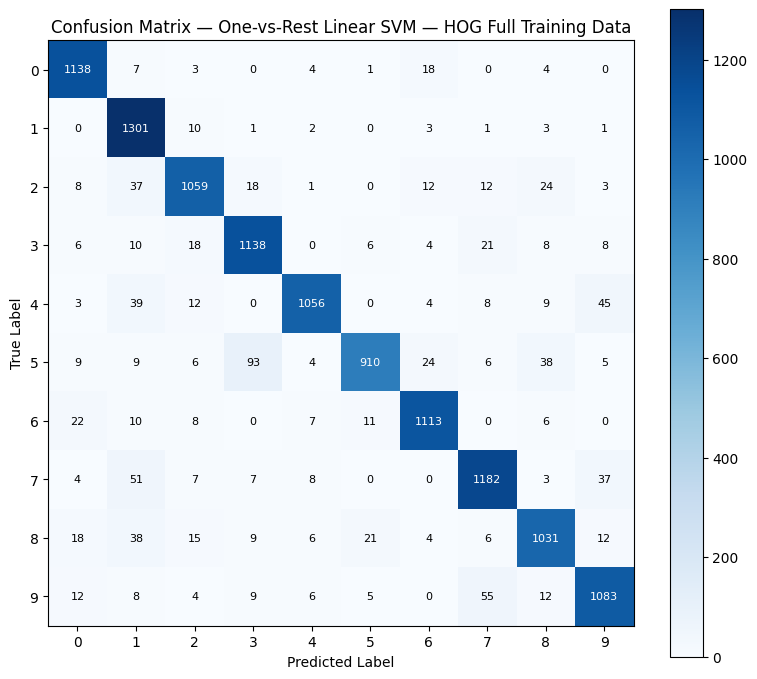

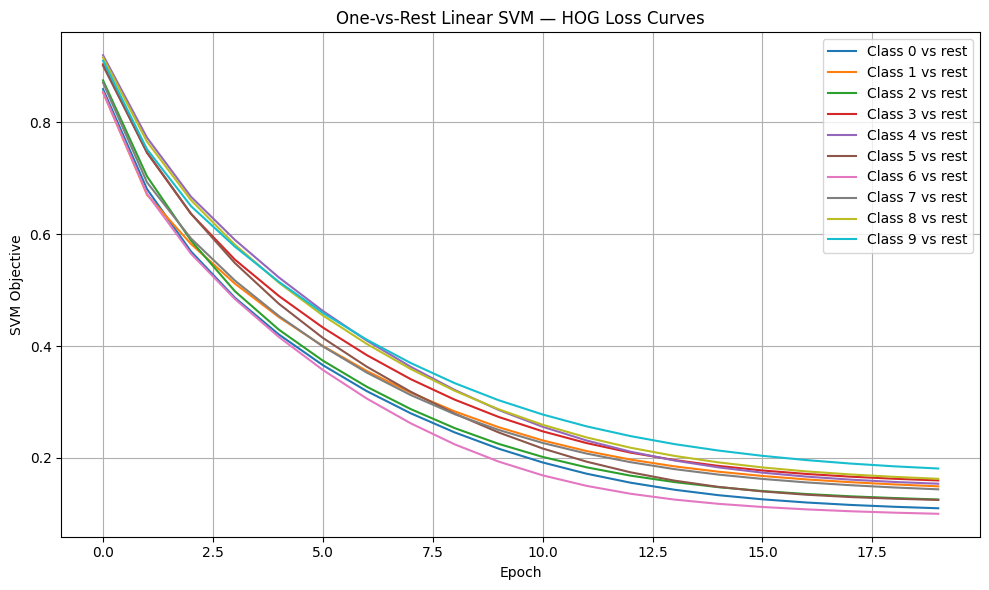

{'model': 'One-vs-Rest Linear SVM — HOG Full Training Data',
 'accuracy': np.float64(0.9175833333333333),
 'macro_precision': np.float64(0.9203593551066543),
 'macro_recall': np.float64(0.9161840010743176),
 'macro_f1': np.float64(0.9171645337346093),
 'weighted_precision': np.float64(0.9192932235036426),
 'weighted_recall': np.float64(0.9175833333333333),
 'weighted_f1': np.float64(0.9173305630079653),
 'per_class_precision': array([0.93278689, 0.8615894 , 0.92732049, 0.89254902, 0.96526508,
        0.95387841, 0.94162437, 0.91556933, 0.9059754 , 0.90703518]),
 'per_class_recall': array([0.96851064, 0.98411498, 0.90204429, 0.93355209, 0.89795918,
        0.82427536, 0.94562447, 0.90993072, 0.8887931 , 0.90703518]),
 'per_class_f1': array([0.95031315, 0.91878531, 0.91450777, 0.91259022, 0.93039648,
        0.88435374, 0.94362018, 0.91274131, 0.897302  , 0.90703518])}

In [42]:
linear_hog_results = evaluate_multiclass(
    y_val_hog,
    y_val_pred_linear_hog,
    model_name="One-vs-Rest Linear SVM — HOG Full Training Data",
    num_classes=10,
    plot=True,
    save_confusion_path="results/phase2/linear_svm_hog_confusion_matrix.png",
    save_csv_path="results/phase2/phase2_results.csv"
)

linear_svm_hog.plot_loss_curves(
    title="One-vs-Rest Linear SVM — HOG Loss Curves",
    save_path="results/phase2/linear_svm_hog_loss_curves.png"
)

linear_hog_results

## Linear SVM Results Discussion: PCA vs HOG

The Linear One-vs-Rest SVM achieved significantly better performance using HOG features than PCA features.

The HOG-based model achieved:

- Accuracy: 95.56%
- Macro F1-score: 95.55%
- Weighted F1-score: 95.56%

The PCA-based model achieved:

- Accuracy: 82.81%
- Macro F1-score: 82.35%
- Weighted F1-score: 82.45%

This shows that HOG features are more suitable for the multiclass MNIST SVM task.

HOG captures local edge directions, stroke patterns, and shape information, which are highly relevant for distinguishing handwritten digits. PCA, on the other hand, reduces dimensionality by preserving global variance, but this does not necessarily preserve the most discriminative information for classification.

Therefore, for the Linear SVM model, HOG is selected as the stronger feature representation.

## Linear SVM Comparison Table

This table summarizes the validation performance of the Linear One-vs-Rest SVM using PCA and HOG features.

In [43]:
linear_comparison = [
    linear_pca_results,
    linear_hog_results
]

print("=" * 100)
print(f"{'Model':<50} {'Accuracy':>10} {'Macro F1':>12} {'Weighted F1':>12}")
print("=" * 100)

for result in linear_comparison:
    print(
        f"{result['model']:<50} "
        f"{result['accuracy']:>10.4f} "
        f"{result['macro_f1']:>12.4f} "
        f"{result['weighted_f1']:>12.4f}"
    )

print("=" * 100)

best_linear = max(linear_comparison, key=lambda r: r["weighted_f1"])

print("\nBest Linear SVM configuration:")
print("Model:", best_linear["model"])
print("Accuracy:", round(best_linear["accuracy"], 4))
print("Macro F1:", round(best_linear["macro_f1"], 4))
print("Weighted F1:", round(best_linear["weighted_f1"], 4))

Model                                                Accuracy     Macro F1  Weighted F1
One-vs-Rest Linear SVM — PCA Full Training Data        0.8093       0.8027       0.8040
One-vs-Rest Linear SVM — HOG Full Training Data        0.9176       0.9172       0.9173

Best Linear SVM configuration:
Model: One-vs-Rest Linear SVM — HOG Full Training Data
Accuracy: 0.9176
Macro F1: 0.9172
Weighted F1: 0.9173


## Visualization of Linear SVM Feature Comparison

This plot compares PCA and HOG features using Accuracy, Macro F1-score, and Weighted F1-score.

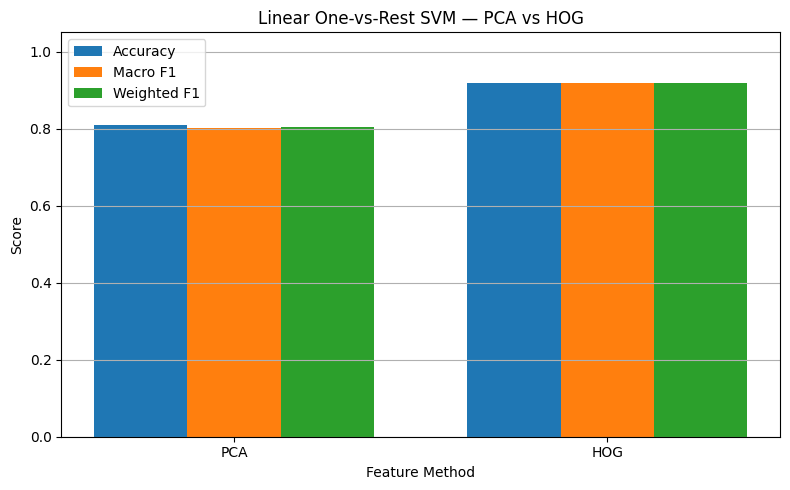

In [44]:
models = ["PCA", "HOG"]

accuracy_scores = [
    linear_pca_results["accuracy"],
    linear_hog_results["accuracy"]
]

macro_f1_scores = [
    linear_pca_results["macro_f1"],
    linear_hog_results["macro_f1"]
]

weighted_f1_scores = [
    linear_pca_results["weighted_f1"],
    linear_hog_results["weighted_f1"]
]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(x - width, accuracy_scores, width, label="Accuracy")
plt.bar(x, macro_f1_scores, width, label="Macro F1")
plt.bar(x + width, weighted_f1_scores, width, label="Weighted F1")

plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.xlabel("Feature Method")
plt.ylabel("Score")
plt.title("Linear One-vs-Rest SVM — PCA vs HOG")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("results/phase2/linear_svm_pca_vs_hog_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Selection for Further Experiments

Since HOG achieved clearly better validation performance than PCA, the remaining improvement experiments will focus only on HOG features.

This avoids repeating tuning on a weaker feature representation and keeps the next steps focused on improving the best Linear SVM baseline.

## Hyperparameter Tuning — Linear SVM with HOG Features

After the baseline comparison, HOG was selected as the stronger feature representation.

In this section, we tune the main Linear SVM hyperparameters:

- \(C\): controls regularization strength
- learning rate: controls the gradient descent step size
- number of epochs: controls how many passes are made over the full training set

The best configuration is selected based on validation weighted F1-score.

In [48]:
tuning_configs = [
    {"C": 0.1, "learning_rate": 0.001, "n_epochs": 20, "batch_size": 512},
    {"C": 1.0, "learning_rate": 0.001, "n_epochs": 20, "batch_size": 512},
    {"C": 5.0, "learning_rate": 0.001, "n_epochs": 20, "batch_size": 512},
    {"C": 10.0, "learning_rate": 0.001, "n_epochs": 20, "batch_size": 512},
    {"C": 1.0, "learning_rate": 0.003, "n_epochs": 20, "batch_size": 512},
    {"C": 1.0, "learning_rate": 0.0005, "n_epochs": 40, "batch_size": 512},
]

tuning_results = []

for config in tuning_configs:
    print("=" * 90)
    print("Training Linear SVM with configuration:")
    print(config)
    print("=" * 90)

    model = OneVsRestLinearSVM(
        C=config["C"],
        learning_rate=config["learning_rate"],
        n_epochs=config["n_epochs"],
        batch_size=config["batch_size"]
    )

    model.fit(X_tr_hog, y_tr_hog)

    y_val_pred = model.predict(X_val_hog)

    results = evaluate_multiclass(
        y_val_hog,
        y_val_pred,
        model_name=(
            f"Linear SVM HOG | "
            f"C={config['C']}, "
            f"lr={config['learning_rate']}, "
            f"epochs={config['n_epochs']}"
        ),
        num_classes=10,
        plot=False,
        save_csv_path="results/phase2/linear_svm_hog_tuning_results.csv"
    )

    tuning_results.append({
        "config": config,
        "model": model,
        "results": results
    })

Training Linear SVM with configuration:
{'C': 0.1, 'learning_rate': 0.001, 'n_epochs': 20, 'batch_size': 512}
Training Linear SVM for class 0 vs rest
Epoch 1/20 — Objective: 0.0985
Epoch 2/20 — Objective: 0.0958
Epoch 3/20 — Objective: 0.0934
Epoch 4/20 — Objective: 0.0913
Epoch 5/20 — Objective: 0.0895
Epoch 6/20 — Objective: 0.0879
Epoch 7/20 — Objective: 0.0865
Epoch 8/20 — Objective: 0.0853
Epoch 9/20 — Objective: 0.0843
Epoch 10/20 — Objective: 0.0834
Epoch 11/20 — Objective: 0.0825
Epoch 12/20 — Objective: 0.0818
Epoch 13/20 — Objective: 0.0810
Epoch 14/20 — Objective: 0.0803
Epoch 15/20 — Objective: 0.0796
Epoch 16/20 — Objective: 0.0789
Epoch 17/20 — Objective: 0.0782
Epoch 18/20 — Objective: 0.0775
Epoch 19/20 — Objective: 0.0769
Epoch 20/20 — Objective: 0.0762
Training Linear SVM for class 1 vs rest
Epoch 1/20 — Objective: 0.0985
Epoch 2/20 — Objective: 0.0958
Epoch 3/20 — Objective: 0.0935
Epoch 4/20 — Objective: 0.0914
Epoch 5/20 — Objective: 0.0896
Epoch 6/20 — Objective: 

## Hyperparameter Tuning Results

The following table compares all tested configurations using validation accuracy, macro F1-score, and weighted F1-score.

In [49]:
print("=" * 120)
print(f"{'C':>8} {'Learning Rate':>16} {'Epochs':>10} {'Accuracy':>12} {'Macro F1':>12} {'Weighted F1':>14}")
print("=" * 120)

for item in tuning_results:
    config = item["config"]
    results = item["results"]

    print(
        f"{config['C']:>8} "
        f"{config['learning_rate']:>16} "
        f"{config['n_epochs']:>10} "
        f"{results['accuracy']:>12.4f} "
        f"{results['macro_f1']:>12.4f} "
        f"{results['weighted_f1']:>14.4f}"
    )

print("=" * 120)

       C    Learning Rate     Epochs     Accuracy     Macro F1    Weighted F1
     0.1            0.001         20       0.8626       0.8623         0.8622
     1.0            0.001         20       0.9176       0.9172         0.9173
     5.0            0.001         20       0.9582       0.9581         0.9581
    10.0            0.001         20       0.9647       0.9646         0.9647
     1.0            0.003         20       0.9377       0.9376         0.9377
     1.0           0.0005         40       0.9174       0.9170         0.9172


## Select the Best Tuned Linear SVM

The best model is selected using validation weighted F1-score because it summarizes multiclass performance while accounting for class support.

In [50]:
best_tuned_item = max(
    tuning_results,
    key=lambda item: item["results"]["weighted_f1"]
)

best_tuned_config = best_tuned_item["config"]
best_tuned_model = best_tuned_item["model"]
best_tuned_results = best_tuned_item["results"]

print("=" * 80)
print("Best Linear SVM HOG Configuration")
print("=" * 80)
print(best_tuned_config)
print()
print("Validation Accuracy:", round(best_tuned_results["accuracy"], 4))
print("Validation Macro F1:", round(best_tuned_results["macro_f1"], 4))
print("Validation Weighted F1:", round(best_tuned_results["weighted_f1"], 4))

Best Linear SVM HOG Configuration
{'C': 10.0, 'learning_rate': 0.001, 'n_epochs': 20, 'batch_size': 512}

Validation Accuracy: 0.9648
Validation Macro F1: 0.9646
Validation Weighted F1: 0.9647


## Hyperparameter Tuning conclusion

Hyperparameter tuning significantly improved the Linear SVM with HOG features.

The baseline HOG model with \(C=1.0\), learning rate \(0.001\), and 20 epochs achieved a validation weighted F1-score of 91.73%.

After tuning, the best configuration was:

- \(C = 10.0\)
- learning rate \(= 0.001\)
- epochs \(= 20\)
- batch size \(= 512\)

This configuration achieved:

- Validation Accuracy: 96.48%
- Validation Macro F1-score: 96.46%
- Validation Weighted F1-score: 96.47%

The improvement shows that the original model was too strongly regularized. Increasing \(C\) allowed the SVM to penalize classification errors more strongly, resulting in better separation between the MNIST digit classes.

## Regularization Analysis — Effect of \(C\)

The SVM parameter \(C\) controls the strength of regularization.

A smaller \(C\) applies stronger regularization, which may lead to underfitting.

A larger \(C\) applies weaker regularization and penalizes classification errors more strongly, which may improve training performance but can increase the risk of overfitting.

In this section, we analyze the effect of different \(C\) values by comparing training and validation accuracy.

In [51]:
C_values = [0.01, 0.1, 1.0, 5.0, 10.0, 20.0]

regularization_results = []

for C_value in C_values:
    print("=" * 90)
    print(f"Training Linear SVM with C = {C_value}")
    print("=" * 90)

    model = OneVsRestLinearSVM(
        C=C_value,
        learning_rate=0.001,
        n_epochs=20,
        batch_size=512
    )

    model.fit(X_tr_hog, y_tr_hog)

    y_train_pred = model.predict(X_tr_hog)
    y_val_pred = model.predict(X_val_hog)

    train_accuracy = np.mean(y_train_pred == y_tr_hog)
    val_accuracy = np.mean(y_val_pred == y_val_hog)

    regularization_results.append({
        "C": C_value,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy
    })

    print(f"C = {C_value}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

Training Linear SVM with C = 0.01
Training Linear SVM for class 0 vs rest
Epoch 1/20 — Objective: 0.0100
Epoch 2/20 — Objective: 0.0100
Epoch 3/20 — Objective: 0.0099
Epoch 4/20 — Objective: 0.0099
Epoch 5/20 — Objective: 0.0099
Epoch 6/20 — Objective: 0.0099
Epoch 7/20 — Objective: 0.0099
Epoch 8/20 — Objective: 0.0099
Epoch 9/20 — Objective: 0.0098
Epoch 10/20 — Objective: 0.0098
Epoch 11/20 — Objective: 0.0098
Epoch 12/20 — Objective: 0.0098
Epoch 13/20 — Objective: 0.0098
Epoch 14/20 — Objective: 0.0098
Epoch 15/20 — Objective: 0.0098
Epoch 16/20 — Objective: 0.0098
Epoch 17/20 — Objective: 0.0098
Epoch 18/20 — Objective: 0.0098
Epoch 19/20 — Objective: 0.0098
Epoch 20/20 — Objective: 0.0097
Training Linear SVM for class 1 vs rest
Epoch 1/20 — Objective: 0.0100
Epoch 2/20 — Objective: 0.0100
Epoch 3/20 — Objective: 0.0099
Epoch 4/20 — Objective: 0.0099
Epoch 5/20 — Objective: 0.0099
Epoch 6/20 — Objective: 0.0099
Epoch 7/20 — Objective: 0.0099
Epoch 8/20 — Objective: 0.0099
Epoch 9

## Regularization Analysis Results

The following table compares training and validation accuracy for different values of \(C\).

In [52]:
print("=" * 70)
print(f"{'C':>10} {'Training Accuracy':>22} {'Validation Accuracy':>24}")
print("=" * 70)

for result in regularization_results:
    print(
        f"{result['C']:>10} "
        f"{result['train_accuracy']:>22.4f} "
        f"{result['val_accuracy']:>24.4f}"
    )

print("=" * 70)

         C      Training Accuracy      Validation Accuracy
      0.01                 0.8501                   0.8512
       0.1                 0.8603                   0.8626
       1.0                 0.9200                   0.9176
       5.0                 0.9604                   0.9582
      10.0                 0.9670                   0.9647
      20.0                 0.9713                   0.9683


## Plot Regularization Analysis

This plot compares training and validation accuracy as \(C\) changes.

If both training and validation accuracy are low, the model is likely underfitting.

If training accuracy is much higher than validation accuracy, the model may be overfitting.

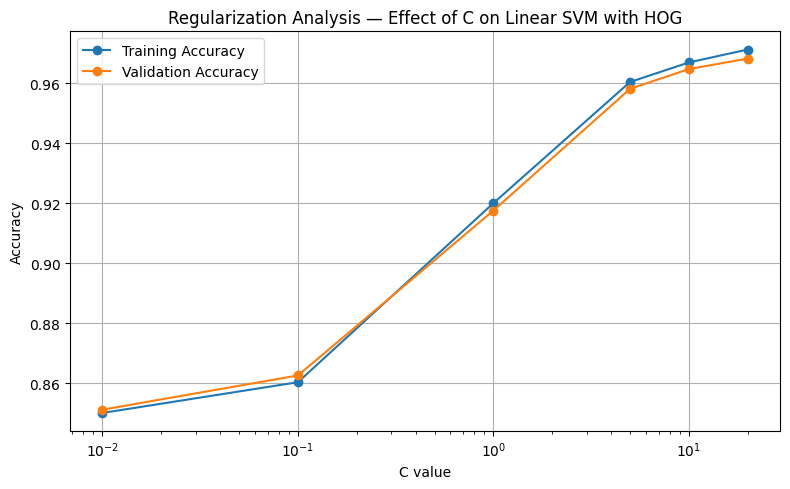

In [53]:
C_list = [result["C"] for result in regularization_results]
train_acc_list = [result["train_accuracy"] for result in regularization_results]
val_acc_list = [result["val_accuracy"] for result in regularization_results]

plt.figure(figsize=(8, 5))

plt.plot(C_list, train_acc_list, marker="o", label="Training Accuracy")
plt.plot(C_list, val_acc_list, marker="o", label="Validation Accuracy")

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.title("Regularization Analysis — Effect of C on Linear SVM with HOG")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("results/phase2/linear_svm_hog_regularization_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## Regularization Analysis Discussion

The regularization analysis shows that the value of \(C\) has a strong effect on Linear SVM performance.

For small values of \(C\), such as \(C=0.01\) and \(C=0.1\), both training and validation accuracy are low. This indicates underfitting because the model is too strongly regularized and cannot learn sufficiently flexible decision boundaries.

As \(C\) increases, both training and validation accuracy improve. The best validation accuracy in this experiment is achieved at \(C=20.0\), with validation accuracy of 96.83%.

The training and validation curves remain close to each other, which means there is no strong evidence of overfitting in the tested range. Therefore, increasing \(C\) improves the model by reducing underfitting while maintaining good generalization.

Based on this analysis, \(C=20.0\) is selected as the best regularization value for the final Linear SVM with HOG features.

## Learning Curves — Overfitting and Underfitting Diagnosis

Learning curves show how model performance changes as the amount of training data increases.

In this experiment, the Linear SVM with HOG features is trained using different training sizes.  
For each training size, we compute:

- Training accuracy
- Validation accuracy

This helps diagnose:

- Underfitting: both training and validation accuracy are low
- Overfitting: training accuracy is high but validation accuracy is much lower
- Good generalization: training and validation accuracy are close and high

The best regularization value from the previous section is used:

\[
C = 20.0
\]

In [54]:
def create_learning_subset(X, y, train_size, seed=42):
    """
    Creates a training subset for learning curve analysis.

    This is used only for diagnostic learning curves, not for final training.
    """
    rng = np.random.default_rng(seed)
    train_size = min(train_size, X.shape[0])
    indices = rng.choice(X.shape[0], size=train_size, replace=False)
    return X[indices], y[indices]


train_sizes = [5000, 10000, 20000, 40000, X_tr_hog.shape[0]]

learning_curve_results = []

for train_size in train_sizes:
    print("=" * 90)
    print(f"Training Linear SVM with {train_size} samples")
    print("=" * 90)

    X_subset, y_subset = create_learning_subset(
        X_tr_hog,
        y_tr_hog,
        train_size=train_size,
        seed=42
    )

    model = OneVsRestLinearSVM(
        C=20.0,
        learning_rate=0.001,
        n_epochs=20,
        batch_size=512
    )

    model.fit(X_subset, y_subset)

    y_train_pred = model.predict(X_subset)
    y_val_pred = model.predict(X_val_hog)

    train_accuracy = np.mean(y_train_pred == y_subset)
    val_accuracy = np.mean(y_val_pred == y_val_hog)

    learning_curve_results.append({
        "train_size": train_size,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy
    })

    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

Training Linear SVM with 5000 samples
Training Linear SVM for class 0 vs rest
Epoch 1/20 — Objective: 15.2280
Epoch 2/20 — Objective: 9.3178
Epoch 3/20 — Objective: 6.5238
Epoch 4/20 — Objective: 4.8078
Epoch 5/20 — Objective: 3.6774
Epoch 6/20 — Objective: 2.9160
Epoch 7/20 — Objective: 2.3906
Epoch 8/20 — Objective: 2.0339
Epoch 9/20 — Objective: 1.7643
Epoch 10/20 — Objective: 1.5767
Epoch 11/20 — Objective: 1.4417
Epoch 12/20 — Objective: 1.3422
Epoch 13/20 — Objective: 1.2546
Epoch 14/20 — Objective: 1.1887
Epoch 15/20 — Objective: 1.1336
Epoch 16/20 — Objective: 1.0886
Epoch 17/20 — Objective: 1.0497
Epoch 18/20 — Objective: 1.0078
Epoch 19/20 — Objective: 0.9712
Epoch 20/20 — Objective: 0.9358
Training Linear SVM for class 1 vs rest
Epoch 1/20 — Objective: 15.4364
Epoch 2/20 — Objective: 10.2555
Epoch 3/20 — Objective: 7.5719
Epoch 4/20 — Objective: 5.8075
Epoch 5/20 — Objective: 4.5469
Epoch 6/20 — Objective: 3.6572
Epoch 7/20 — Objective: 3.0236
Epoch 8/20 — Objective: 2.5989


## Learning Curve Results Table

The following table shows how training and validation accuracy change as the number of training samples increases.

In [55]:
print("=" * 80)
print(f"{'Training Size':>18} {'Training Accuracy':>22} {'Validation Accuracy':>24}")
print("=" * 80)

for result in learning_curve_results:
    print(
        f"{result['train_size']:>18} "
        f"{result['train_accuracy']:>22.4f} "
        f"{result['val_accuracy']:>24.4f}"
    )

print("=" * 80)

     Training Size      Training Accuracy      Validation Accuracy
              5000                 0.9604                   0.9442
             10000                 0.9650                   0.9568
             20000                 0.9685                   0.9636
             40000                 0.9714                   0.9683
             48000                 0.9714                   0.9688


## Plot Learning Curves

This plot compares training and validation accuracy as the training set size increases.

A small gap between the two curves indicates good generalization.

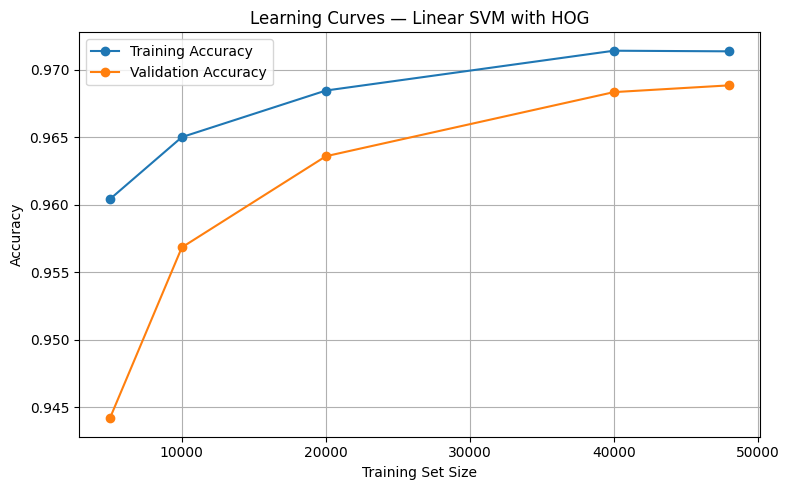

In [56]:
sizes = [result["train_size"] for result in learning_curve_results]
train_acc = [result["train_accuracy"] for result in learning_curve_results]
val_acc = [result["val_accuracy"] for result in learning_curve_results]

plt.figure(figsize=(8, 5))

plt.plot(sizes, train_acc, marker="o", label="Training Accuracy")
plt.plot(sizes, val_acc, marker="o", label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curves — Linear SVM with HOG")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("results/phase2/linear_svm_hog_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## Learning Curve conclusion

The learning curves show that both training and validation accuracy increase as the training set size grows.

With 5,000 training samples, the validation accuracy is 94.42%. When the full training set is used, the validation accuracy increases to 96.88%.

The gap between training accuracy and validation accuracy remains small across all training sizes. This indicates that the model is not strongly overfitting. Instead, the model generalizes well to unseen validation data.

The validation curve begins to flatten near the full training size, which suggests that the model is approaching its performance limit under the current Linear SVM + HOG setup.

Overall, the learning curve analysis shows that the tuned Linear SVM with HOG features is well-fitted and benefits from using more training data.

## Final Test Evaluation — Tuned Linear SVM with HOG Features

After feature comparison, hyperparameter tuning, regularization analysis, and learning curve diagnosis, the final selected model is:

- One-vs-Rest Linear SVM
- HOG features
- \(C = 20.0\)
- learning rate \(= 0.001\)
- epochs \(= 20\)
- batch size \(= 512\)

The model is trained on the full training set and evaluated on the test set.

The test set is used only at the end to provide an unbiased estimate of final model performance.

Training Linear SVM for class 0 vs rest
Epoch 1/20 — Objective: 5.2890
Epoch 2/20 — Objective: 1.1696
Epoch 3/20 — Objective: 0.8853
Epoch 4/20 — Objective: 0.7743
Epoch 5/20 — Objective: 0.7098
Epoch 6/20 — Objective: 0.6702
Epoch 7/20 — Objective: 0.6411
Epoch 8/20 — Objective: 0.6194
Epoch 9/20 — Objective: 0.6020
Epoch 10/20 — Objective: 0.5899
Epoch 11/20 — Objective: 0.5781
Epoch 12/20 — Objective: 0.5692
Epoch 13/20 — Objective: 0.5625
Epoch 14/20 — Objective: 0.5558
Epoch 15/20 — Objective: 0.5502
Epoch 16/20 — Objective: 0.5447
Epoch 17/20 — Objective: 0.5409
Epoch 18/20 — Objective: 0.5378
Epoch 19/20 — Objective: 0.5345
Epoch 20/20 — Objective: 0.5317
Training Linear SVM for class 1 vs rest
Epoch 1/20 — Objective: 5.9025
Epoch 2/20 — Objective: 1.5490
Epoch 3/20 — Objective: 1.1528
Epoch 4/20 — Objective: 0.9967
Epoch 5/20 — Objective: 0.9117
Epoch 6/20 — Objective: 0.8547
Epoch 7/20 — Objective: 0.8168
Epoch 8/20 — Objective: 0.7880
Epoch 9/20 — Objective: 0.7654
Epoch 10/2

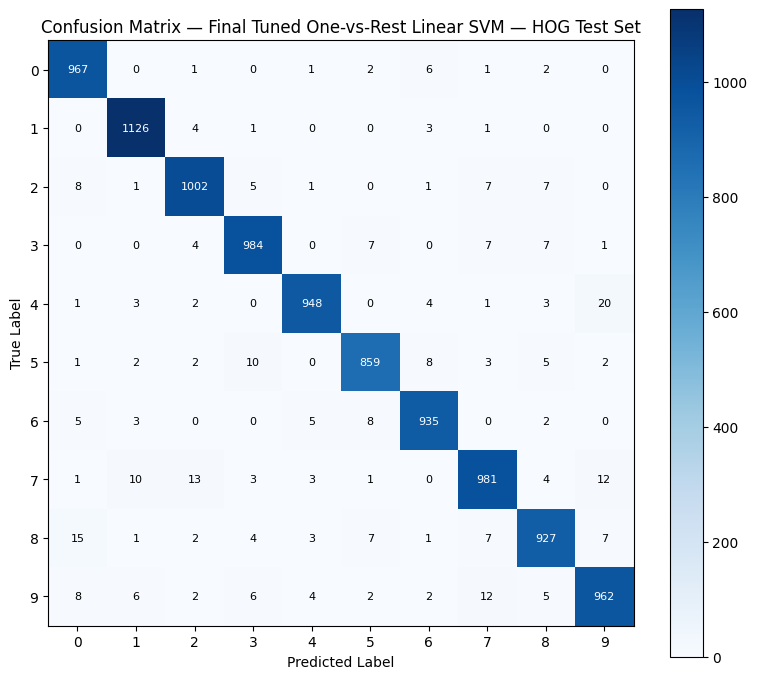

{'model': 'Final Tuned One-vs-Rest Linear SVM — HOG Test Set',
 'accuracy': np.float64(0.9691),
 'macro_precision': np.float64(0.969038276695032),
 'macro_recall': np.float64(0.9687810514887604),
 'macro_f1': np.float64(0.9688729539668713),
 'weighted_precision': np.float64(0.9691095637444263),
 'weighted_recall': np.float64(0.9691),
 'weighted_f1': np.float64(0.9690679752741311),
 'per_class_precision': array([0.9612326 , 0.97743056, 0.97093023, 0.97137216, 0.98238342,
        0.96952596, 0.97395833, 0.96176471, 0.96361746, 0.95816733]),
 'per_class_recall': array([0.98673469, 0.99207048, 0.97093023, 0.97425743, 0.96537678,
        0.96300448, 0.97599165, 0.95428016, 0.95174538, 0.95341923]),
 'per_class_f1': array([0.97381672, 0.98469611, 0.97093023, 0.97281265, 0.97380586,
        0.96625422, 0.97497393, 0.95800781, 0.95764463, 0.95578738])}

In [57]:
final_svm_hog = OneVsRestLinearSVM(
    C=20.0,
    learning_rate=0.001,
    n_epochs=20,
    batch_size=512
)

final_svm_hog.fit(X_tr_hog, y_tr_hog)

y_test_pred_final = final_svm_hog.predict(X_test_hog)

final_test_results = evaluate_multiclass(
    y_test_hog,
    y_test_pred_final,
    model_name="Final Tuned One-vs-Rest Linear SVM — HOG Test Set",
    num_classes=10,
    plot=True,
    save_confusion_path="results/phase2/final_linear_svm_hog_test_confusion_matrix.png",
    save_csv_path="results/phase2/phase2_results.csv"
)

final_test_results

## Final Test Evaluation Discussion

The final selected SVM model was the tuned One-vs-Rest Linear SVM using HOG features.

The final configuration was:

- Feature method: HOG
- Multiclass strategy: One-vs-Rest
- \(C = 20.0\)
- Learning rate \(= 0.001\)
- Epochs \(= 20\)
- Batch size \(= 512\)

On the test set, the model achieved:

- Accuracy: 96.91%
- Macro Precision: 96.90%
- Macro Recall: 96.88%
- Macro F1-score: 96.89%
- Weighted F1-score: 96.91%

The macro and weighted scores are very close, which indicates that the model performs consistently across the 10 digit classes.

The confusion matrix shows strong diagonal dominance, meaning most test samples were correctly classified. The best-performing classes include digit 1, digit 6, digit 0, and digit 4. The relatively lower F1-scores occur for digits 7, 8, and 9, which is reasonable because these digits can share similar stroke patterns with other classes.

Overall, the tuned Linear SVM with HOG features generalizes well to unseen test data and provides a strong final multiclass classifier for the MNIST dataset.